# Model Training

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [2]:
df= pd.read_csv('./data/StudentsPerformance.csv')

In [3]:
df.head(3)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


#### Checking the unique categorical values in the features

In [4]:
print(f"Unique categories in the gender column==>   {', '.join(df.gender.unique().tolist())}")
print(f"Unique categories in the gender race/ethnicity==>   {', '.join(df['race/ethnicity'].unique().tolist())}")
print(f"Unique categories in the parental level of education column==>  {', '.join(df['parental level of education'].unique().tolist())}")
print(f"Unique categories in the lunch column==>    {', '.join(df.lunch.unique().tolist())}")
print(f"Unique categories in the test preparation course column==>  {', '.join(df['test preparation course'].unique().tolist())}")

Unique categories in the gender column==>   female, male
Unique categories in the gender race/ethnicity==>   group B, group C, group A, group D, group E
Unique categories in the parental level of education column==>  bachelor's degree, some college, master's degree, associate's degree, high school, some high school
Unique categories in the lunch column==>    standard, free/reduced
Unique categories in the test preparation course column==>  none, completed


#### Splitting into dependent and independent features

In [5]:
x=df.drop(columns=['math score'])
y=df['math score']

In [6]:
x.head(3), y.head(3)

(   gender race/ethnicity parental level of education     lunch  \
 0  female        group B           bachelor's degree  standard   
 1  female        group C                some college  standard   
 2  female        group B             master's degree  standard   
 
   test preparation course  reading score  writing score  
 0                    none             72             74  
 1               completed             90             88  
 2                    none             95             93  ,
 0    72
 1    69
 2    90
 Name: math score, dtype: int64)

#### Train test split

In [7]:
x_train,x_test, y_train,y_test= train_test_split(x,y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape

((800, 7), (200, 7))

#### Creating the pipeline

In [8]:
numerical_features= x.select_dtypes(include=np.number).columns
categorical_features= x.select_dtypes(include='string').columns

In [9]:
from sklearn.compose import ColumnTransformer

In [10]:
numerical_transformation= StandardScaler()
categorical_transformation= OneHotEncoder(drop='first')

preprocessor= ColumnTransformer(
    [
        ('Numerical Transformation', numerical_transformation, numerical_features),
        ('Categorical Transformation', categorical_transformation, categorical_features)
    ]
)


In [11]:
x_train= preprocessor.fit_transform(x_train)
x_test= preprocessor.transform(x_test)

In [12]:
x_train.shape, x_test.shape

((800, 14), (200, 14))

Function generation

In [13]:
def evaluate_model(true,predicted):
    r_sqt_score= r2_score(y_true=true, y_pred=predicted)
    mse= mean_squared_error(y_true=true, y_pred=predicted)
    mae= mean_absolute_error(y_true=true, y_pred=predicted)
    rmse= np.sqrt(mse)

    return (r_sqt_score, mse, rmse,mae)

#### Model Evaluation

In [20]:
models={
    'Linear Regression': LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "K Nearest Neighbor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forrest": RandomForestRegressor(),
    "AdaBoostClassifier": AdaBoostRegressor(),
    "XGBoost": XGBRegressor(),
    "CatBoost": CatBoostRegressor(verbose=False)
}

model_list=[]
r2_list=[]

for i in range(len(models)):
    model= list(models.values())[i]
    model.fit(x_train,y_train)

    y_pred_train= model.predict(x_train)
    y_pred_test= model.predict(x_test)

    r_sqt_score_train, mse_train, rmse_train, mae_train= evaluate_model(true=y_train,predicted=y_pred_train)
    r_sqt_score_test, mse_test, rmse_test, mae_test= evaluate_model(true=y_test,predicted=y_pred_test)

    model_list.append(list(models.keys())[i])
    r2_list.append(r_sqt_score_test)

    print("="*10 ,f"{list(models.keys())[i]}","="*10)
    
    print(f"Model Performance on Training Set:")
    print(f"MSE: {mse_train}")
    print(f"RMSE: {rmse_train}")
    print(f"MAE: {mae_train}")
    print(f"R2 Score: {r_sqt_score_train}")

    print('-'*30)

    print(f"Model Performance on Testing Set:")
    print(f"MSE: {mse_test}")
    print(f"RMSE: {rmse_test}")
    print(f"MAE: {mae_test}")
    print(f"R2 Score: {r_sqt_score_test}")

    print("="*40,)
    print("="*40,)



========== Linear Regression ==========
Model Performance on Training Set:
MSE: 28.334870380648585
RMSE: 5.323050852720513
MAE: 4.266711846071957
R2 Score: 0.8743172040139593
------------------------------
Model Performance on Testing Set:
MSE: 29.095169866715494
RMSE: 5.393993869732843
MAE: 4.214763142474851
R2 Score: 0.8804332983749564
========== Ridge ==========
Model Performance on Training Set:
MSE: 28.33963485875215
RMSE: 5.323498366558606
MAE: 4.26500882127927
R2 Score: 0.8742960705864395
------------------------------
Model Performance on Testing Set:
MSE: 29.091086457465472
RMSE: 5.393615342000714
MAE: 4.212526820759745
R2 Score: 0.8804500791594525
========== Lasso ==========
Model Performance on Training Set:
MSE: 43.46106018771194
RMSE: 6.592500298650879
MAE: 5.205260274468427
R2 Score: 0.8072231322208645
------------------------------
Model Performance on Testing Set:
MSE: 42.47556715227398
RMSE: 6.517328221922997
MAE: 5.155701094273797
R2 Score: 0.8254465092551198
========

In [21]:
pd.DataFrame(list(zip(model_list, r2_list)) ,columns=["Model", "R2 score"])

,Model,R2 score
0,Linear Regression,0.880433
1,Ridge,0.880450
2,Lasso,0.825447
3,K Nearest Neighbor,0.778020
4,Decision Tree,0.741430
5,Random Forrest,0.849641
6,AdaBoostClassifier,0.845202
7,XGBoost,0.820924
8,CatBoost,0.850263


#### Selected model
Linear regression shows the best performance

### Fine-tuning the model

In [22]:
param={
    "fit_intercept": [True, False],
    'positive': [True, False],
    'copy_X': [True, False]
}

In [23]:
randomCv= RandomizedSearchCV(estimator=LinearRegression(), param_distributions=param, n_iter=50, cv=5, n_jobs=8, random_state=42)

In [27]:
randomCv.fit(x_train, y_train)
y_pred_train=randomCv.predict(x_train)
y_pred_test=randomCv.predict(x_test)

/mnt/H-Drive/AI_ML/PROJECTS/StudentsPerformance_DS-ML/venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=50. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [36]:
r_sqt_score_train, mse_train, rmse_train, mae_train= evaluate_model(true=y_train,predicted=y_pred_train)
r_sqt_score_test, mse_test, rmse_test, mae_test= evaluate_model(true=y_test,predicted=y_pred_test)

print(f"Model Performance on Training Set:")
print(f"MSE: {mse_train}")
print(f"RMSE: {rmse_train}")
print(f"MAE: {mae_train}")
print(f"R2 Score: {r_sqt_score_train:.2%}")

print('-'*30)

print(f"Model Performance on Testing Set:")
print(f"MSE: {mse_test}")
print(f"RMSE: {rmse_test}")
print(f"MAE: {mae_test}")
print(f"R2 Score: {r_sqt_score_test:.2%}")

Model Performance on Training Set:
MSE: 28.468195788676834
RMSE: 5.335559557223294
MAE: 4.2769861356137815
R2 Score: 87.37%
------------------------------
Model Performance on Testing Set:
MSE: 29.22937910239345
RMSE: 5.406420174421653
MAE: 4.221003375619831
R2 Score: 87.99%


#### Plotting y_pred and y_true

Text(0, 0.5, 'Predict')

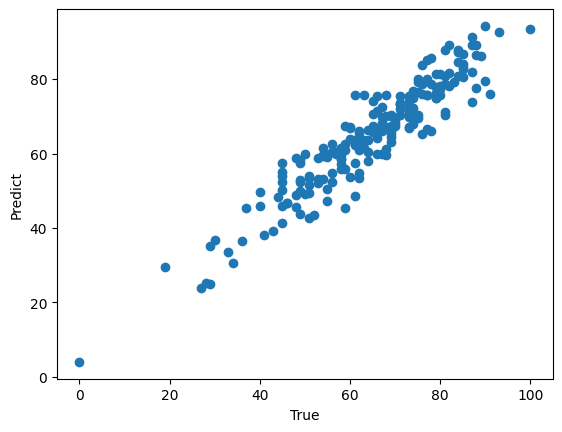

In [38]:
plt.scatter(y_test,y_pred_test)
plt.xlabel("True")
plt.ylabel("Predict")

<Axes: xlabel='math score'>

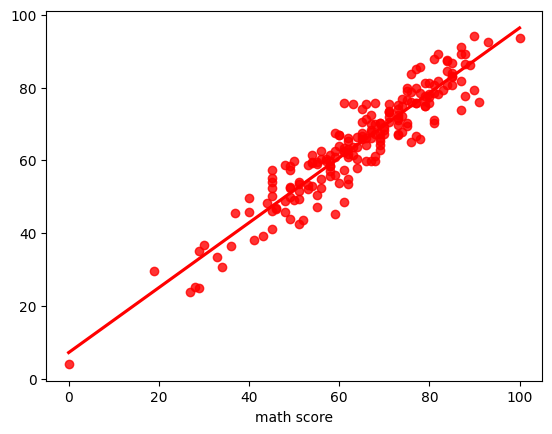

In [39]:
sns.regplot(x=y_test,y=y_pred_test,ci=None,color ='red')